In [1]:
import torch
import time

import sys
sys.path.append('./FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic')
from flocat import flocatTrainer, flocat

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
def load_embeddings(path):
    return torch.load(path, map_location="cpu")

inlier_topic = "bottle"

data_train = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/train.pt")
X_train = data_train["embeddings"]          

data_test = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/test.pt")
X_test = data_test["embeddings"]
y_test = data_test["labels"]

/tmp/ipykernel_2682673/3574879467.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


In [16]:
batch_size = 32
num_patches = X_train.shape[1]
attentions_train_mask = torch.ones((X_train.shape[0], num_patches), dtype=torch.long)
attentions_test_mask = torch.ones((X_test.shape[0], num_patches), dtype=torch.long)

flocat_config = {
    "latent_dim": X_train.shape[-1], "hidden_dim": 64, "depth": 2, "n_heads": 2,
    "freq_embed_size": 128, "lr": 1e-3, "weight_decay": 1e-4, "lambda_love": 1e-3,
    "epochs": 20, "lr_epochs": 5, "batch_size": batch_size,
    "coef_var": 1.0, "target": "gaussian-neigh", "source": X_train,
    "attentions_mask": attentions_train_mask, "device": device,
}
flow_model = flocat(
    latent_dim=flocat_config["latent_dim"],
    hidden_dim=flocat_config["hidden_dim"],
    depth=flocat_config["depth"],
    n_heads=flocat_config["n_heads"],
).to(device)
flocatformer = flocatTrainer(flow_model, flocat_config)

t0 = time.time()
flocatformer.train(True)
t1 = time.time()
auc, fpr, ap = flocatformer.test(
    X_test, y_test, attentions_test_mask, type="norm-centroid", n_steps=10,
)
print(f"FLOCAT-GENAGN --> AUC: {auc:.4f} | FPR@95: {fpr:.4f} | AP: {ap:.4f}\n")


Epoch 1/20
Train Loss: 1.1161, LR: 0.000167
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 7/20
Train Loss: 1.1139, LR: 0.000989
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 13/20
Train Loss: 1.0946, LR: 0.000552
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 19/20
Train Loss: 1.0798, LR: 0.000043
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)
AUC:        0.9413
Avg Precision: 0.9820
FPR@95:     0.3500
FLOCAT-GENAGN --> AUC: 0.9413 | FPR@95: 0.3500 | AP: 0.9820



In [17]:
all_x_final, all_velocities, all_x_inter = flocatformer.euler_integrate(
    X_test.to(device),
    attentions_test_mask.to(device),
    5, True
)

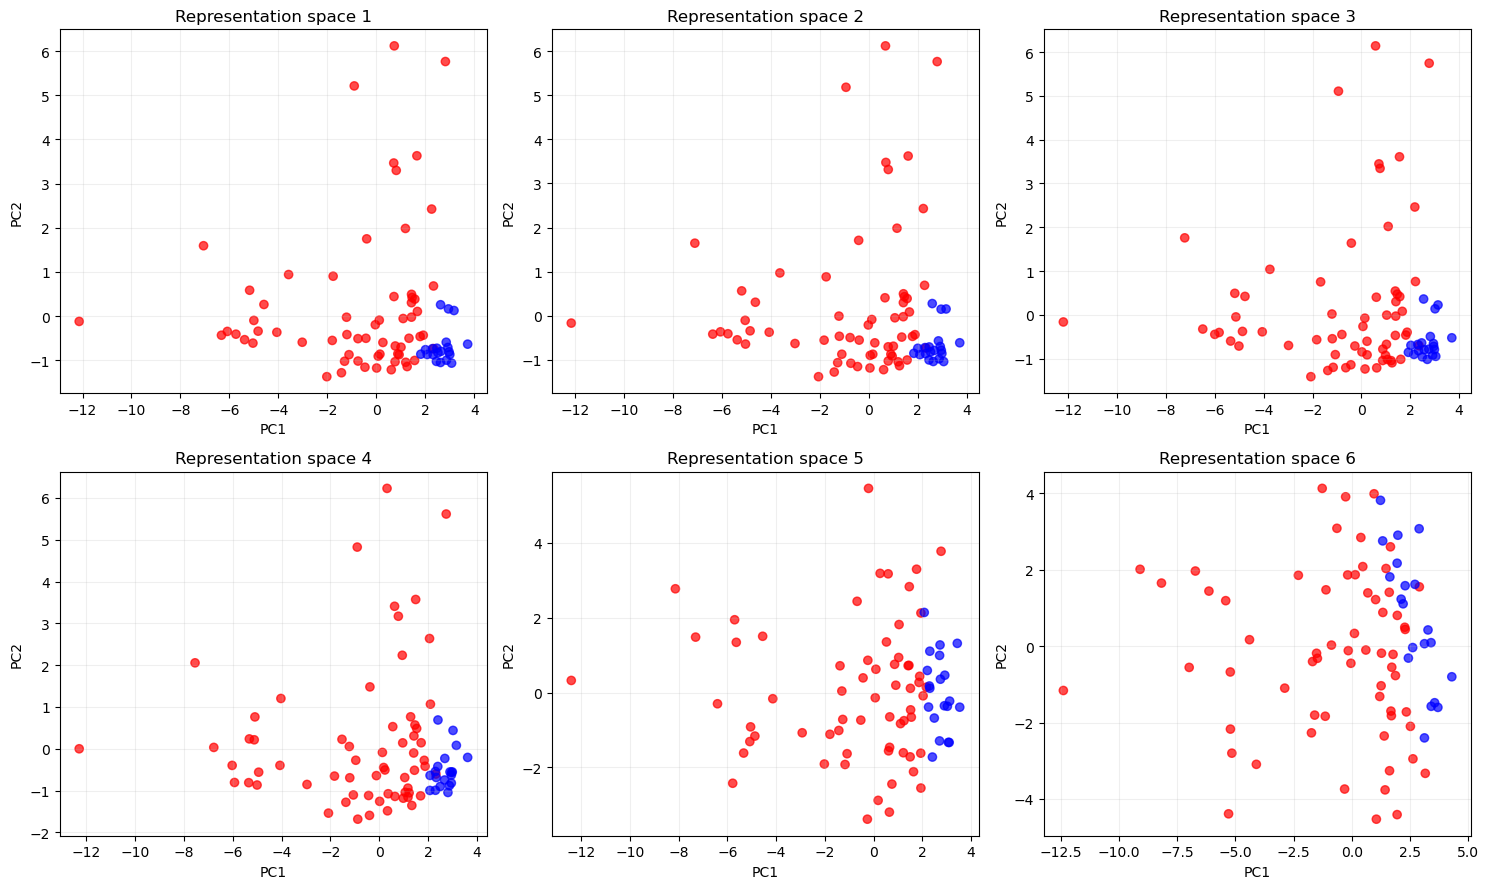

In [18]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# X : [6, 83, 1536]
# y_test : [83]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Couleurs : 0 -> bleu, 1 -> rouge
colors = ['blue' if y == 0 else 'red' for y in y_test]

for i in range(6):

    X_i = all_x_inter[i].detach().cpu().numpy()

    # PCA 1536 -> 2
    pca = PCA(n_components=2)
    X_i_pca = pca.fit_transform(X_i)

    axes[i].scatter(
        X_i_pca[:, 0],
        X_i_pca[:, 1],
        c=colors,
        alpha=0.7
    )

    axes[i].set_title(f"Representation space {i+1}")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()